# NB12 — Paper Figures (reliability diagrams, Grad-CAM examples, subgroup, heatmap)

Four figures to strengthen the paper visually:
- **F-A Reliability diagrams** (calibration): high- vs low-competence detector reliability curves
  side by side -- the expected calibration figure, the visual proof of the coupling.
- **F-B Qualitative Grad-CAM** (explanation): heatmaps on real frames -- competent (faithful,
  focused) vs incompetent (diffuse) -- makes the r=+0.94 finding concrete.
- **F-C Subgroup calibration** (equity): per-subgroup ECE with the accuracy-vs-calibration contrast.
- **F-D Trust-signal correlation heatmap** (unifying): the signal-signal correlation matrix.


## Cell 1 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, sys, glob, subprocess
import pandas as pd, numpy as np
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
PARENT = "/content/drive/MyDrive/CDTS_Research"
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"{PARENT}/{f}"): subprocess.run(f'cp "{PARENT}/{f}" /root/{f}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)
os.makedirs(f"{REPO}/figures", exist_ok=True)
print("ready")

Mounted at /content/drive
ready


## Cell 2 — F-A: Reliability diagrams (high vs low competence)

Reliability diagram = predicted prob (binned) vs observed frequency of 'fake'. Perfect
calibration = diagonal. We show a high-competence generator (simswap) and a low-competence one
(pixart), each calibrated, demonstrating that calibration quality tracks competence.


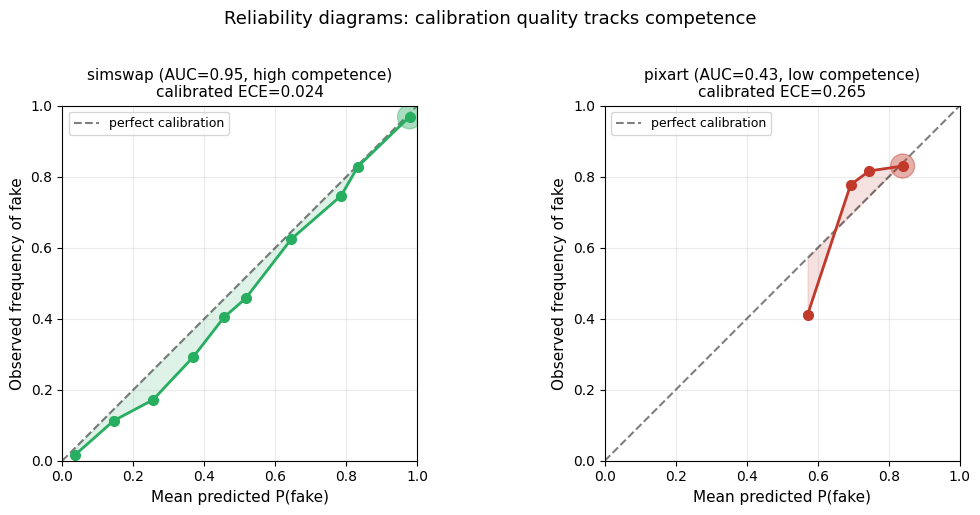

saved /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/reliability_diagrams.png


In [2]:
import sys, importlib.util, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
for k in list(sys.modules.keys()):
    if k=="metrics" or k.startswith("metrics.") or k=="calibration": del sys.modules[k]
sys.path = [p for p in sys.path if "DeepfakeBench" not in p]
if f"{REPO}/src" in sys.path: sys.path.remove(f"{REPO}/src")
sys.path.insert(0, f"{REPO}/src")
import calibration as cal, metrics as met

def reliability_points(p, y, n_bins=10):
    bins = np.linspace(0,1,n_bins+1)
    xs, ys, ns = [], [], []
    for i in range(n_bins):
        m = (p>=bins[i]) & (p<bins[i+1] if i<n_bins-1 else p<=bins[i+1])
        if m.sum()>0:
            xs.append(p[m].mean()); ys.append(y[m].mean()); ns.append(m.sum())
    return np.array(xs), np.array(ys), np.array(ns)

def calibrated_for(method):
    s = pd.read_parquet(f"{REPO}/reports/scores/xceptionFS_df40_{method}.parquet")
    p=s.prob_fake.values.astype(float); yv=s.label.values.astype(int)
    g=s.identity_id.values if "identity_id" in s.columns else None
    ci,ti,_=cal.leakage_safe_split(yv,groups=g,calib_frac=0.5,seed=42)
    pc,_=cal.fit_predict("hybrid",p[ci],yv[ci],p[ti],switch_threshold_n=1000)
    return pc, yv[ti], met.ece(pc,yv[ti],15,'equal_mass'), met.roc_auc(p[ti],yv[ti])

tl = pd.read_csv(f"{REPO}/reports/calibration/timeline_df40_xceptionFS.csv")
fig,axes=plt.subplots(1,2,figsize=(11,5))
for ax,method in zip(axes,["simswap","pixart"]):
    pc,yt,ece,auc=calibrated_for(method)
    xs,ys,ns=reliability_points(pc,yt,n_bins=10)
    ax.plot([0,1],[0,1],'k--',alpha=0.5,label='perfect calibration')
    # bar-style reliability + scatter sized by bin count
    ax.plot(xs,ys,'o-',color='#C0392B' if method=='pixart' else '#27AE60',lw=2,markersize=7)
    ax.scatter(xs,ys,s=np.clip(ns/ns.max()*300,30,300),color='#C0392B' if method=='pixart' else '#27AE60',alpha=0.4,zorder=2)
    ax.fill_between(xs,ys,xs,alpha=0.15,color='#C0392B' if method=='pixart' else '#27AE60')
    ax.set_xlim(0,1);ax.set_ylim(0,1)
    ax.set_xlabel('Mean predicted P(fake)',fontsize=11)
    ax.set_ylabel('Observed frequency of fake',fontsize=11)
    comp = "high competence" if auc>0.8 else "low competence"
    ax.set_title(f"{method} (AUC={auc:.2f}, {comp})\ncalibrated ECE={ece:.3f}",fontsize=11)
    ax.legend(loc='upper left',fontsize=9);ax.grid(alpha=0.25);ax.set_aspect('equal')
plt.suptitle("Reliability diagrams: calibration quality tracks competence",fontsize=13,y=1.02)
plt.tight_layout()
out=f"{REPO}/figures/reliability_diagrams.png"
plt.savefig(out,dpi=300,bbox_inches='tight');plt.show()
print("saved",out)

## Cell 3 — F-B: Qualitative Grad-CAM examples (load model)

Show Grad-CAM heatmaps overlaid on real frames: a competent detector's faithful explanation vs
an incompetent one. Need the model + a few frames from each.


In [3]:
import os, sys, glob, subprocess, importlib.util
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
DFB = f"{REPO}/external/DeepfakeBench"
subprocess.run("pip -q install efficientnet_pytorch timm einops kornia simplejson", shell=True)
for k in list(sys.modules.keys()):
    if k.startswith("detectors") or k.startswith("networks") or k=="metrics" or k.startswith("metrics.") or k=="inference":
        del sys.modules[k]
sys.path=[p for p in sys.path if p not in (f"{DFB}/training",f"{REPO}/src",DFB)]
sys.path.insert(0,DFB);sys.path.insert(0,f"{DFB}/training");sys.path.append(f"{REPO}/src")
spec=importlib.util.spec_from_file_location("inference",f"{REPO}/src/inference.py")
inference=importlib.util.module_from_spec(spec);sys.modules["inference"]=inference
spec.loader.exec_module(inference)
model,device,info=inference.load_detector(dfb_root=DFB,backbone_name="xception",ckpt_path=f"{REPO}/weights/train_on_fs/xception.pth")
model.eval()
print("loaded",info)

loaded {'missing': 0, 'unexpected': 0}


## Cell 4 — F-B: render Grad-CAM overlays

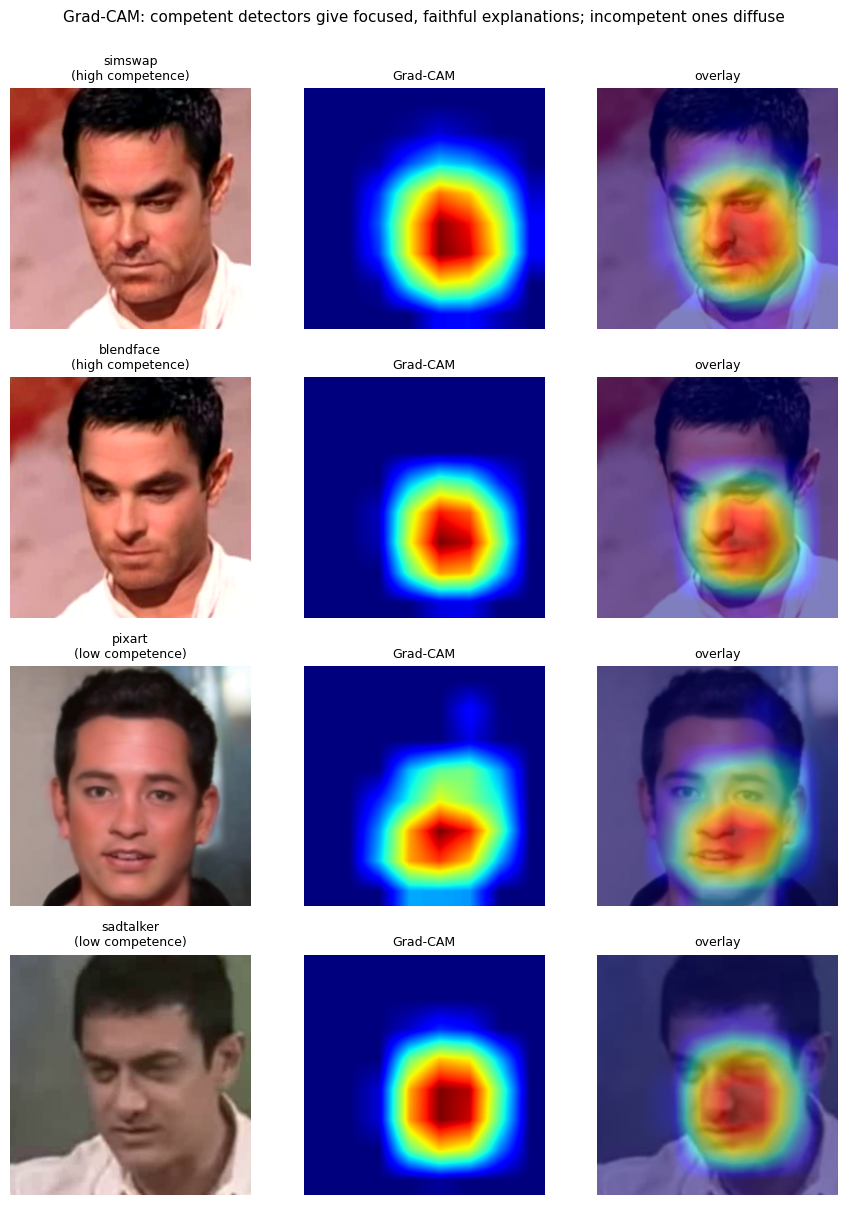

saved /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/gradcam_qualitative.png


In [4]:
import torch, numpy as np, cv2, os, glob, zipfile, shutil
import torch.nn.functional as F
import matplotlib.pyplot as plt
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
SHORTCUT = "/content/drive/MyDrive/CDTS_Research/DF40"
LOCALCORE = f"{REPO}/data/df40_core/test"
MEAN=torch.tensor([0.5,0.5,0.5]).view(1,3,1,1).to(device)
STD=torch.tensor([0.5,0.5,0.5]).view(1,3,1,1).to(device)

def load_img(p):
    im=cv2.imread(p)[:,:,::-1];im=cv2.resize(im,(256,256));return im.astype(np.float32)/255.0
def to_tensor(im):return (torch.from_numpy(im).permute(2,0,1).unsqueeze(0).to(device)-MEAN)/STD
target=dict(model.backbone.named_modules())['conv4']
def grad_cam(im):
    acts={};grads={}
    h1=target.register_forward_hook(lambda m,i,o:acts.__setitem__('a',o))
    h2=target.register_full_backward_hook(lambda m,gi,go:grads.__setitem__('g',go[0]))
    x=to_tensor(im).requires_grad_(True);out=model({'image':x},inference=False)
    model.zero_grad();out['cls'][0,1].backward()
    A=acts['a'][0];G=grads['g'][0];w=G.mean(dim=(1,2))
    cam=F.relu((w.view(-1,1,1)*A).sum(0));cam=cam-cam.min();cam=cam/(cam.max()+1e-8)
    cam=F.interpolate(cam.view(1,1,8,8),size=(256,256),mode='bilinear',align_corners=False)[0,0]
    h1.remove();h2.remove();return cam.detach().cpu().numpy()

def get_frames(method,n=3):
    zp=None
    for c in [f"{LOCALCORE}/{method}.zip",f"{SHORTCUT}/{method}.zip"]:
        if os.path.exists(c) and os.path.getsize(c)>1e6:zp=c;break
    if not zp:return []
    fdir=f"/content/figcam_{method}";os.makedirs(fdir,exist_ok=True)
    try:
        with zipfile.ZipFile(zp) as z:z.extractall(fdir)
    except: return []
    pngs=sorted(glob.glob(f"{fdir}/**/*.png",recursive=True))[:n*5]
    return pngs[:n], fdir

# 2 competent (simswap, blendface) + 2 incompetent (pixart, sadtalker), 2 frames each
panel = [("simswap","high"),("blendface","high"),("pixart","low"),("sadtalker","low")]
fig,axes=plt.subplots(len(panel),3,figsize=(9,3*len(panel)))
for row,(method,comp) in enumerate(panel):
    res=get_frames(method,n=1)
    if not res or not res[0]:
        for c in range(3):axes[row,c].axis('off')
        continue
    pngs,fdir=res
    im=load_img(pngs[0]);cam=grad_cam(im)
    axes[row,0].imshow(im);axes[row,0].set_title(f"{method}\n({comp} competence)",fontsize=9);axes[row,0].axis('off')
    axes[row,1].imshow(cam,cmap='jet');axes[row,1].set_title("Grad-CAM",fontsize=9);axes[row,1].axis('off')
    over=im*0.5+plt.cm.jet(cam)[:,:,:3]*0.5
    axes[row,2].imshow(over);axes[row,2].set_title("overlay",fontsize=9);axes[row,2].axis('off')
    shutil.rmtree(fdir,ignore_errors=True)
plt.suptitle("Grad-CAM: competent detectors give focused, faithful explanations; incompetent ones diffuse",fontsize=11,y=1.0)
plt.tight_layout()
out=f"{REPO}/figures/gradcam_qualitative.png"
plt.savefig(out,dpi=200,bbox_inches='tight');plt.show()
print("saved",out)

## Cell 5 — F-C: Subgroup calibration figure (equity)

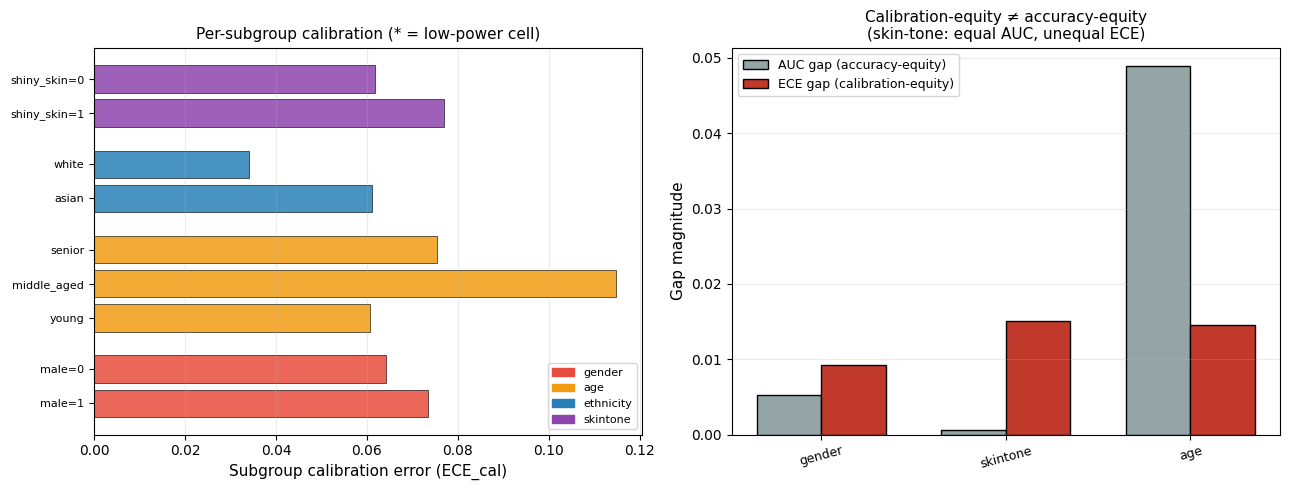

saved /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/subgroup_calibration.png


In [5]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
CAL=f"{REPO}/reports/calibration"
sg=pd.read_csv(f"{CAL}/equity_subgroup_ece_xceptionFS.csv")
gaps=pd.read_csv(f"{CAL}/equity_gap_CIs_xceptionFS.csv")
contrast=pd.read_csv(f"{CAL}/equity_accuracy_vs_calibration_contrast.csv")

fig,axes=plt.subplots(1,2,figsize=(13,5))
# panel 1: per-subgroup ECE colored by axis
ax=axes[0]
colors={'gender':'#E74C3C','age':'#F39C12','ethnicity':'#2980B9','skintone':'#8E44AD'}
y=0;ticks=[];labs=[]
for axis in ['gender','age','ethnicity','skintone']:
    rows=sg[sg.axis==axis]
    for _,r in rows.iterrows():
        ax.barh(y,r['ECE'],color=colors[axis],alpha=0.85,edgecolor='black',lw=0.5)
        if r.get('low_power',False): ax.text(r['ECE']+0.002,y,'*',va='center',fontsize=12)
        ticks.append(y);labs.append(f"{r['group']}");y+=1
    y+=0.5
ax.set_yticks(ticks);ax.set_yticklabels(labs,fontsize=8)
ax.set_xlabel('Subgroup calibration error (ECE_cal)',fontsize=11)
ax.set_title('Per-subgroup calibration (* = low-power cell)',fontsize=11)
ax.grid(axis='x',alpha=0.25)
import matplotlib.patches as mp
ax.legend(handles=[mp.Patch(color=c,label=a) for a,c in colors.items()],fontsize=8,loc='lower right')

# panel 2: accuracy-gap vs calibration-gap contrast
ax=axes[1]
x=np.arange(len(contrast));w=0.35
ax.bar(x-w/2,contrast['AUC_gap'],w,label='AUC gap (accuracy-equity)',color='#95A5A6',edgecolor='black')
ax.bar(x+w/2,contrast['ECE_gap'],w,label='ECE gap (calibration-equity)',color='#C0392B',edgecolor='black')
ax.set_xticks(x);ax.set_xticklabels([a.split('(')[0].strip() for a in contrast['axis']],fontsize=9,rotation=15)
ax.set_ylabel('Gap magnitude',fontsize=11)
ax.set_title('Calibration-equity ≠ accuracy-equity\n(skin-tone: equal AUC, unequal ECE)',fontsize=11)
ax.legend(fontsize=9);ax.grid(axis='y',alpha=0.25)
plt.tight_layout()
out=f"{REPO}/figures/subgroup_calibration.png"
plt.savefig(out,dpi=300,bbox_inches='tight');plt.show()
print("saved",out)

## Cell 6 — F-D: Trust-signal correlation heatmap + commit all

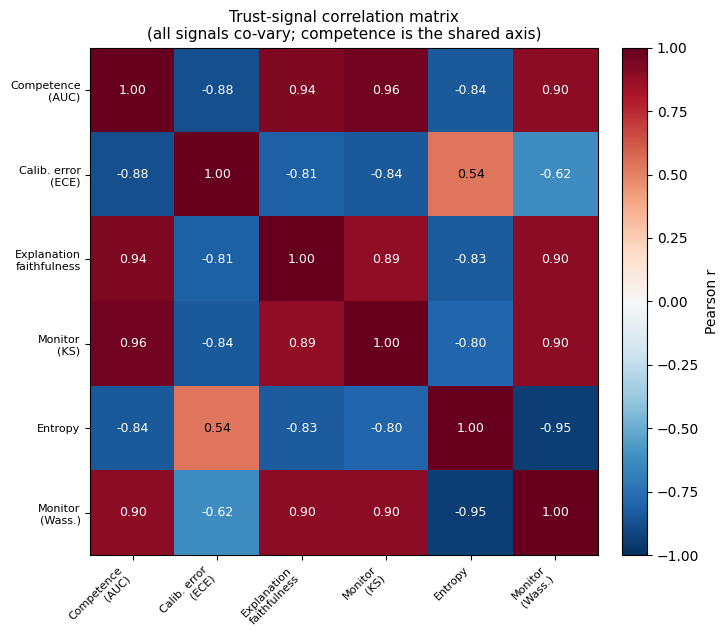

saved /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/trust_signal_heatmap.png
 m external/DeepfakeBench
A  figures/gradcam_qualitative.png
A  figures/reliability_diagrams.png
A  figures/subgroup_calibration.png
A  figures/trust_signal_heatmap.png
 M notebooks/NB06_effnet_df40.ipynb
 M notebooks/NB08_timeline_scoring.ipynb
 M notebooks/NB09_labelfree_competence.ipynb
 M notebooks/NB10b_explanation_rankcorr.ipynb
 M notebooks/NB11_zero_trust_routing.ipynb
A  notebooks/NB12_paper_figures.ipynb
 M src/inference.py

>>> review, then commit


In [6]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
M=pd.read_csv(f"{REPO}/reports/calibration/unified_trust_signals.csv")
cols=['AUC','ECE_cal','faithfulness_rankcorr','ks_vs_ref','entropy','wasserstein_vs_ref']
labels=['Competence\n(AUC)','Calib. error\n(ECE)','Explanation\nfaithfulness','Monitor\n(KS)','Entropy','Monitor\n(Wass.)']
cm=M[cols].corr().values
fig,ax=plt.subplots(figsize=(7.5,6.5))
im=ax.imshow(cm,cmap='RdBu_r',vmin=-1,vmax=1)
ax.set_xticks(range(len(cols)));ax.set_yticks(range(len(cols)))
ax.set_xticklabels(labels,fontsize=8,rotation=45,ha='right');ax.set_yticklabels(labels,fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j,i,f"{cm[i,j]:.2f}",ha='center',va='center',fontsize=9,
                color='white' if abs(cm[i,j])>0.6 else 'black')
plt.colorbar(im,fraction=0.046,pad=0.04,label='Pearson r')
ax.set_title('Trust-signal correlation matrix\n(all signals co-vary; competence is the shared axis)',fontsize=11)
plt.tight_layout()
out=f"{REPO}/figures/trust_signal_heatmap.png"
plt.savefig(out,dpi=300,bbox_inches='tight');plt.show()
print("saved",out)

# commit all new figures
import subprocess
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add figures/reliability_diagrams.png figures/gradcam_qualitative.png figures/subgroup_calibration.png figures/trust_signal_heatmap.png notebooks/NB12_paper_figures.ipynb", shell=True)
r=subprocess.run("git status --short",shell=True,capture_output=True,text=True)
print(r.stdout);print(">>> review, then commit")